Found 844 images belonging to 1 classes.
Found 844 images belonging to 1 classes.
Found 282 images belonging to 1 classes.
Found 282 images belonging to 1 classes.


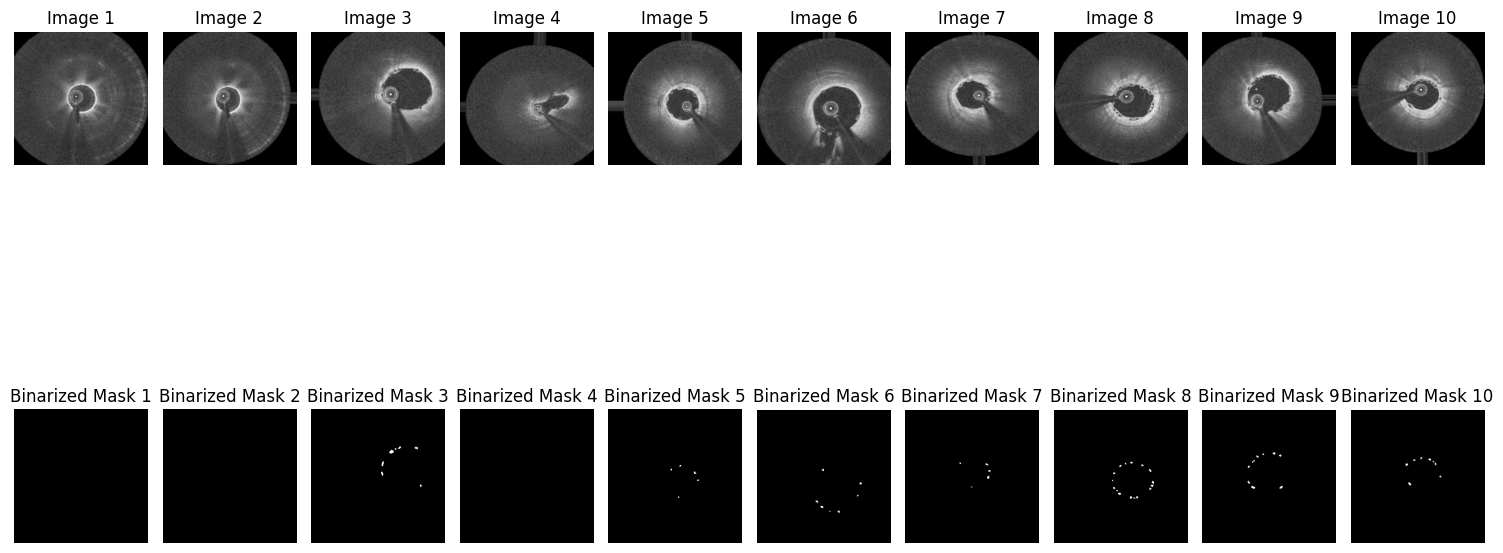

In [5]:
import os
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Définition des chemins
DATA_PATH = '/kaggle/input/finaldb/blop'
TRAIN_FRAME_PATH = os.path.join(DATA_PATH, 'train_images')
VAL_FRAME_PATH = os.path.join(DATA_PATH, 'val_images')
TRAIN_MASK_PATH = os.path.join(DATA_PATH, 'train_masks')
VAL_MASK_PATH = os.path.join(DATA_PATH, 'val_masks')

# Génér
# Générateurs de données avec augmentation pour l'entraînement et normalisation pour validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    rotation_range=2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 1  # Taille de batch ajustée pour de meilleures performances

# Fonction pour binariser les masques
def binarize_batch_masks(mask_batch, threshold=0.5):
    return (mask_batch > threshold).astype(np.float32)

# Synchronisation des générateurs avec binarisation des masques
def sync_generators_with_binarization(image_generator, mask_generator, threshold=0.5):
    for img_batch, mask_batch in zip(image_generator, mask_generator):
        binarized_masks = binarize_batch_masks(mask_batch, threshold=threshold)
        yield img_batch, binarized_masks

# Chargement des données depuis les répertoires
train_image_generator = train_datagen.flow_from_directory(
    TRAIN_FRAME_PATH, target_size=(256, 256), batch_size=BATCH_SIZE, 
    color_mode='grayscale', class_mode=None, seed=123
)
train_mask_generator = train_datagen.flow_from_directory(
    TRAIN_MASK_PATH, target_size=(256, 256), batch_size=BATCH_SIZE, 
    color_mode='grayscale', class_mode=None, seed=123
)
val_image_generator = val_datagen.flow_from_directory(
    VAL_FRAME_PATH, target_size=(256, 256), batch_size=BATCH_SIZE, 
    color_mode='grayscale', class_mode=None, seed=42
)
val_mask_generator = val_datagen.flow_from_directory(
    VAL_MASK_PATH, target_size=(256, 256), batch_size=BATCH_SIZE, 
    color_mode='grayscale', class_mode=None, seed=42
)

# Conversion des générateurs en tf.data.Dataset avec masques binarisés
train_dataset = tf.data.Dataset.from_generator(
    lambda: sync_generators_with_binarization(train_image_generator, train_mask_generator, threshold=0.5),
    output_signature=(
        tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),  # Images
        tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)   # Masques binarisés
    )
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: sync_generators_with_binarization(val_image_generator, val_mask_generator, threshold=0.5),
    output_signature=(
        tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),  # Images
        tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)   # Masques binarisés
    )
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Visualisation des images et masques binarisés
def display_images_and_binarized_masks(image_generator, mask_generator, threshold=0.5, num_images=6):
    plt.figure(figsize=(15, 10))
    for i, (img_batch, mask_batch) in enumerate(sync_generators_with_binarization(image_generator, mask_generator, threshold)):
        if i >= num_images:
            break
        img = np.squeeze(img_batch[0])  # Image originale
        mask = np.squeeze(mask_batch[0])  # Masque binarisé

        # Affichage de l'image
        plt.subplot(2, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Image {i + 1}")
        plt.axis('off')

        # Affichage du masque binarisé
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Binarized Mask {i + 1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Afficher des exemples avec masques binarisés
display_images_and_binarized_masks(train_image_generator, train_mask_generator, threshold=0.5, num_images=10)

# Vous pouvez maintenant entraîner votre modèle avec les masques binarisés



In [6]:

################################################################################
# Building the UNet network architecture                                       #
################################################################################

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose

def get_UNet(img_rows, img_cols):
    inputs = Input((img_rows, img_cols, 1))
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)


    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=[inputs], outputs=[conv10])

    return model


    
    




Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9976 - loss: 0.1546 - val_accuracy: 0.9991 - val_loss: 0.0058
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9984 - loss: 0.0030 - val_accuracy: 0.9994 - val_loss: 0.0020
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9983 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0024
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9994 - val_loss: 0.0021
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9982 - loss: 0.0042 - val_accuracy: 0.9993 - val_loss: 0.0024
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9982 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0017
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9983 - loss: 0.0041 - 

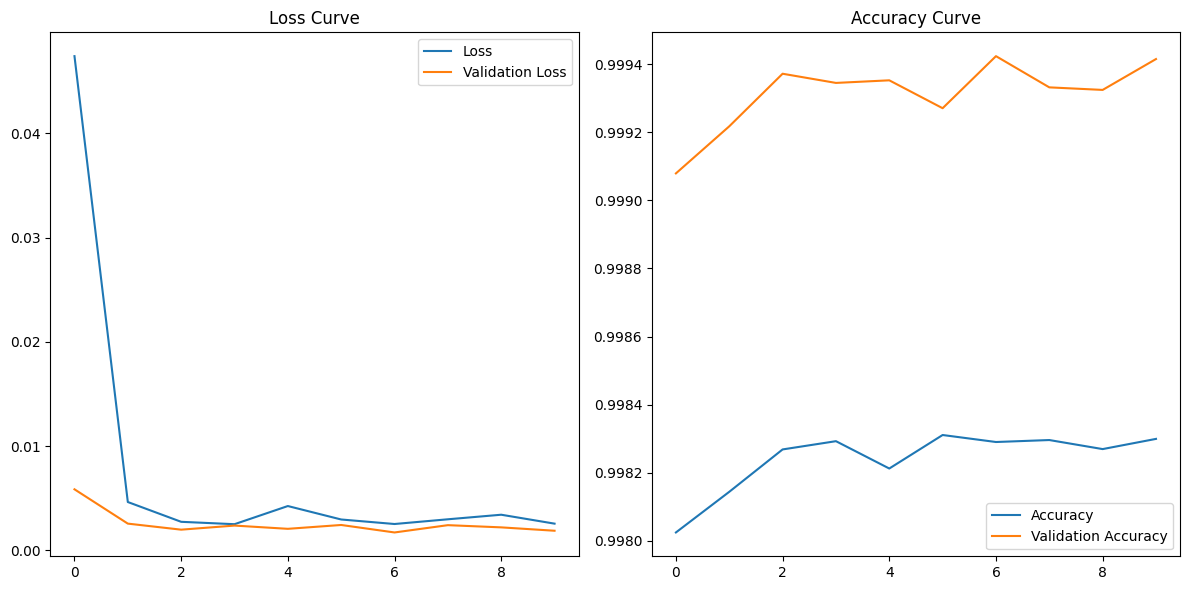

In [7]:
# Fonction pour synchroniser les générateurs d'images et de masques
def sync_generators(image_generator, mask_generator):
    for img_batch, mask_batch in zip(image_generator, mask_generator):
        yield img_batch, mask_batch

# Génération d'un générateur de données combiné pour l'entraînement et la validation
train_generator = sync_generators(train_image_generator, train_mask_generator)
val_generator = sync_generators(val_image_generator, val_mask_generator)

# Construire et compiler le modèle
model = get_UNet(img_rows=256, img_cols=256)  # Utilisation de la fonction get_UNet
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_image_generator),
    validation_steps=len(val_image_generator)
)

# Sauvegarde du modèle
model.save("unet_model_with_binarized_masks.h5")

# Visualisation des courbes de perte et précision
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
# Save final model weights
# Sauvegarder les poids dans un répertoire en écriture
model.save_weights('/kaggle/working/Pif.weights.h5')

# Vérifier si le fichier existe
import os
if os.path.exists('/kaggle/working/Pif.weights.h5'):
    print("Les poids ont été sauvegardés avec succès.")

Les poids ont été sauvegardés avec succès.
